# Goal

The goal of this tutorial notebook is to learn how to use flexAE for classification on the well-established [Iris dataset](https://scikit-learn.org/1.5/auto_examples/datasets/plot_iris_dataset.html). I do want to highlight that using flexAE for this classification problem is overkill. You can classify the dataset correctly with much simpler techniques. But it will work as an example.

Note that I assume that you are already familiar with autoencoders, MLP classifiers, and training models in PyTorch. If not, there are a ton of other amazing resources out there to help you get familiar with that. I'm also assuming you're familiar with the idea of flexAE, as presented in Géron et al. (2026). The point of this notebook is to show you how to specifically use flexAE.

# Imports

In [1]:
# General imports
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import warnings

# Sklearn imports
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.datasets import load_iris, load_breast_cancer

# Pytorch imports
import torch
from torch import optim
from torch.utils.data import TensorDataset
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load flexAE
import sys
sys.path.append("..") #Point this to where the flexAE.py file is located
from flexAE import *

# Code

### Part 1: Loading the data

Let's load the Iris dataset and inspect it. This dataset should have four features. 

In [2]:
iris_dataset = load_iris(as_frame=True)

data = iris_dataset['data']
Y = iris_dataset['target']

In [3]:
# Only keeping two classes, as flexAE currently only supports binary classification. However, flexAE (specifically the classifier component and the classification loss) can be adapted to support multiple classes though. 

inds_keep = np.where((Y == 0) | (Y == 1))[0]

data = data.iloc[inds_keep].reset_index(drop=True)
Y = Y[inds_keep]

In [4]:
data

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
95,5.7,3.0,4.2,1.2
96,5.7,2.9,4.2,1.3
97,6.2,2.9,4.3,1.3
98,5.1,2.5,3.0,1.1


Let's standardize the features and load them into tensors.

In [5]:
# Input
X = data.values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X) #Transform
X_tensor = torch.tensor(X_scaled, dtype=torch.float32) # Convert to PyTorch Tensors
Y_tensor = torch.tensor(Y, dtype=torch.long)
feature_names = data.columns

# Create the Dataset
tensor_dataset = TensorDataset(X_tensor,  Y_tensor)

# Divide into train and test
test_split = 0.2
train_dataset, test_dataset = split_tensordataset(tensor_dataset, train_fraction=0.8)

### Part 2: Training flexAE

Here, we first configure the training parameters, the optimizer, and then initialize the flexAE model with a specific architecture. For this case, we'll load a relatively small model with only two latent space dimensions, as it is a simple classification task.

In [6]:
# Config training parameters
batch_size = 32
epochs = 1_000
learning_rate = 1e-3
validation_split = 0.1

In [7]:
# Initialize model with architecture
model = flexAE(
    input_dim = X_scaled.shape[1],
    hidden_dim = [4,4],
    latent_dim = 2,
    classifier_dim = [4,4]
).to(device)

In [8]:
# Initialize optimizer
optimizer = optim.AdamW(model.parameters(), lr=learning_rate)

In [9]:
# Train
model.train_model(train_dataset, epochs = epochs, learning_rate = learning_rate, batch_size = batch_size,
                  validation_split = validation_split, optimizer = optimizer)

100%|█████████████████████████████████████████████████| 1000/1000 [00:03<00:00, 262.00it/s]


### Part 3: Inspect model performance

We will now inspect how the model performs. There are a lot of methods you can use associated with flexAE to help with this process.

Let's inspect the loss curve. There are two distinct losses in flexAE: the reconstruction and BCE classification loss. In the cell below, you'll notice that both of them are going down for the training and validation set, as expected.

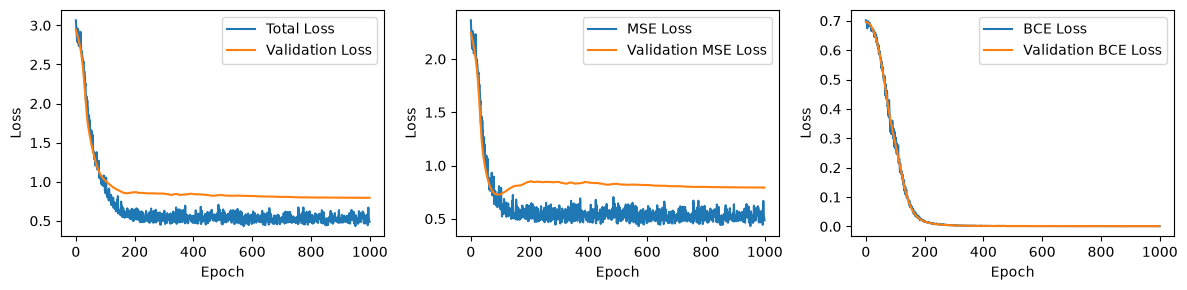

In [10]:
plt.figure(figsize = (12,3))

plt.subplot(1,3,1)
model.plot_loss_per_epoch(losses = ['total','validation'], yscale = 'linear', ax = plt.gca())

plt.subplot(1,3,2)
model.plot_loss_per_epoch(losses = ['mse','val_mse'], yscale = 'linear', ax = plt.gca())

plt.subplot(1,3,3)
model.plot_loss_per_epoch(losses = ['bce','val_bce'], yscale = 'linear', ax = plt.gca())

plt.tight_layout()
plt.show()

Even though the end goal is classification, flexAE also attempts to use its latent space to reconstruct the input features. You can look at the average residuals for each of the input features to get a sense of how good the reconstruction is.

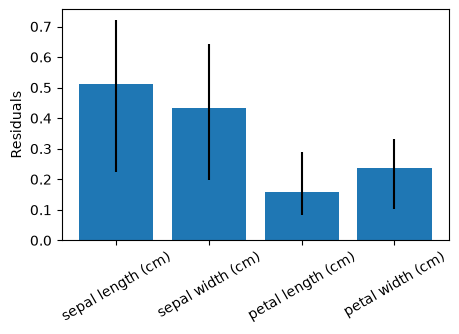

In [11]:
plt.figure(figsize = (5,3))
model.plot_feature_residuals(labels = feature_names, ax = plt.gca())
plt.xticks(rotation = 30)
plt.show()

Instead of looking at the average residuals, you can also directly compare the shape of the input and reconstructed features. It seems like flexAE did an OK job.

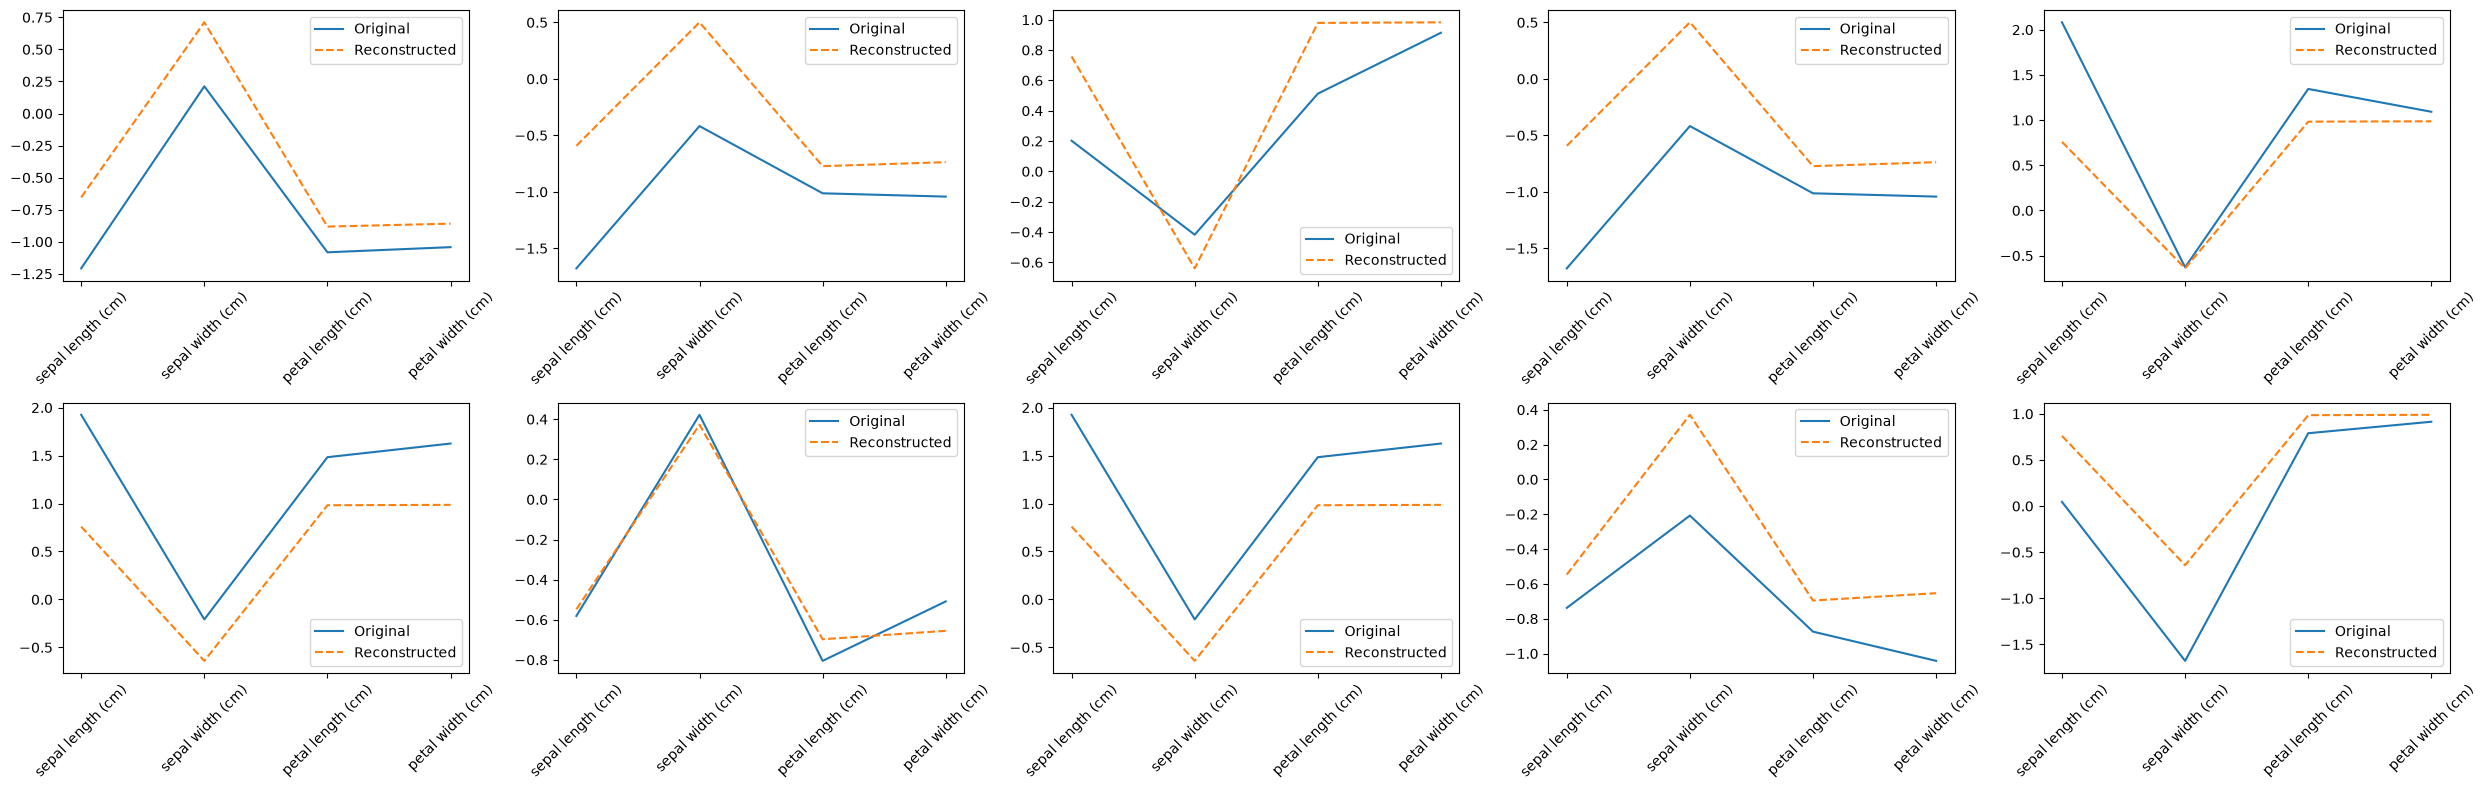

In [12]:
model.compare_reconstructed_features(test_dataset, labels = feature_names)

While reconstruction is important, in this case, we actually mostly care about the classification accuracy. Let's inspect the latent space to see where the two classes are located. We can do this by running the `encode` method on the tensor with the training data, as shown below. This method returns a dictionary with the encoder output, which in out case only includes the latent space locations (saved in `mu`). We're then using seaborn to plot. It seems like the two classes separate out well, which is promising!

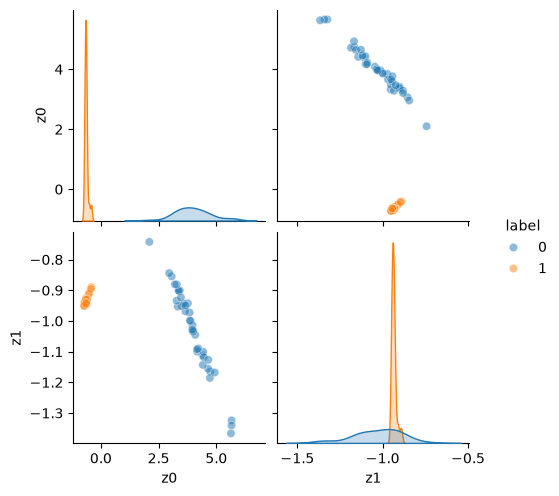

In [13]:
model.eval()
with torch.no_grad():
    data, Y_true = train_dataset.tensors
    Y_true = Y_true.numpy()
    
    encoder_output = model.encode(data)
    mu = encoder_output['mu'].detach().cpu().numpy()


warnings.filterwarnings("ignore", module="seaborn")

df_latent = pd.DataFrame(mu, columns=[f'z{i}' for i in range(mu.shape[1])])
df_latent['label'] = Y_true.astype(str)

sns.pairplot(df_latent, hue='label', diag_kind='kde', plot_kws={'alpha': 0.5})
plt.show()

We will now explicitly look at the classification performance. You can get classification predictions by running `model()` on the tensor with the data. This returns a dictionary that contains the reconstructed features, the latent space locations (mu), and the classification predictions. We care about the latter. It looks like we have a near-perfect classification score for the training set!

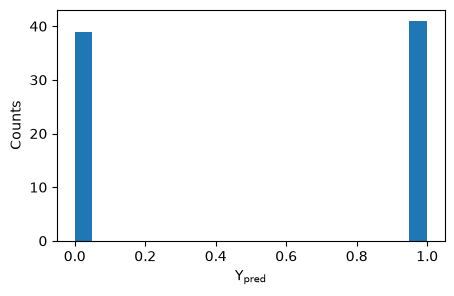

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        39
           1       1.00      1.00      1.00        41

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80



In [14]:
model.eval()
with torch.no_grad():
    data, Y_true = train_dataset.tensors
    results = model(data)
    
    Y_pred = results['classification_prediction'].detach().cpu().numpy()
    Y_pred_labels = (np.array(Y_pred) > 0.5).astype(int) #Use 0.5 as a threshold


plt.figure(figsize = (5,3))
plt.hist(Y_pred, bins = 20)
plt.xlabel(r'Y$_{\rm pred}$')
plt.ylabel('Counts')
plt.show()

print(classification_report(Y_true, Y_pred_labels))

Let's look at how well the model classifies the test set. This code is the same as above, but with the test dataset instead. The model still works well!

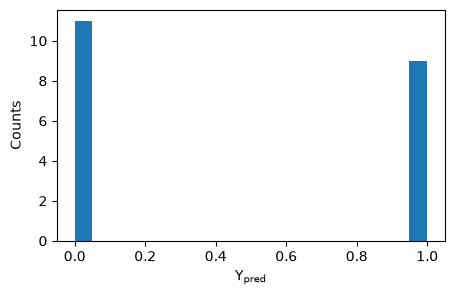

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        11
           1       1.00      1.00      1.00         9

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



In [15]:
model.eval()
with torch.no_grad():
    data, Y_true = test_dataset.tensors
    results = model(data)
    
    Y_pred = results['classification_prediction'].detach().cpu().numpy()
    Y_pred_labels = (np.array(Y_pred) > 0.5).astype(int)


plt.figure(figsize = (5,3))
plt.hist(Y_pred, bins = 20)
plt.xlabel(r'Y$_{\rm pred}$')
plt.ylabel('Counts')
plt.show()

print(classification_report(Y_true, Y_pred_labels))